In [ ]:
import torch
if torch.cuda.is_available():
    print(f"Super! Koristiš GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU nije pronađen. Provjeri postavke u Runtime izborniku.")

Super! Koristiš GPU: Tesla T4


In [ ]:
import os


os.environ['KAGGLE_USERNAME'] = "ivonapranjic"
os.environ['KAGGLE_KEY'] = "KGAT_f7d98dab9d6df3a828a8330f9b0273f9"


!mkdir -p ~/.kaggle
!echo '{"username":"'$KAGGLE_USERNAME'","key":"'$KAGGLE_KEY'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json


print("Skidanje podataka započeto...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip
print("Gotovo! Podaci su spremni.")

Skidanje podataka započeto...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 42.7MB/s]
100% 2.29G/2.29G [00:18<00:00, 130MB/s] 
Gotovo! Podaci su spremni.


Provjera balansa skupova(klasa):

In [ ]:
def count_files(directory):
  for root, dirs, files in os.walk(directory):
    if not dirs:
      print(f"Folder: {os.path.basename(root)} | Broj slika: {len(files)}")

print("Trening skup")
count_files('chest_xray/train')
print("Test skup")
count_files('chest_xray/test')

Trening skup
Folder: NORMAL | Broj slika: 1341
Folder: PNEUMONIA | Broj slika: 3875
Test skup
Folder: NORMAL | Broj slika: 234
Folder: PNEUMONIA | Broj slika: 390


Vizualna usporedba, inicijalna vizualizacija podataka s kojima radimo:

Nasumični uzorci slika zdravih pluća (normal):


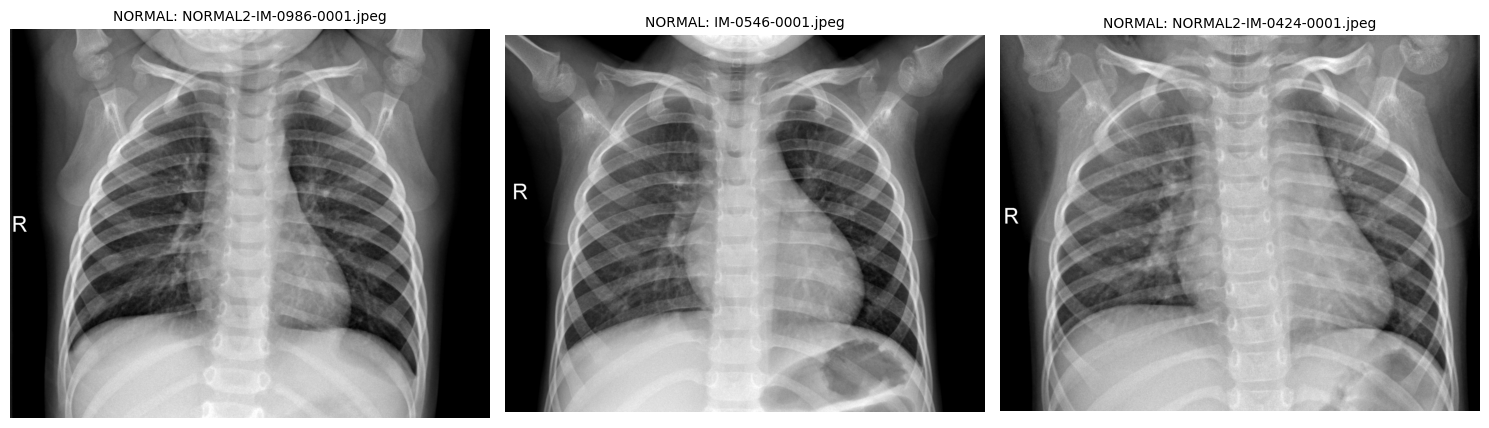


 Nasumični uzorci slika pluća (pneumonia):


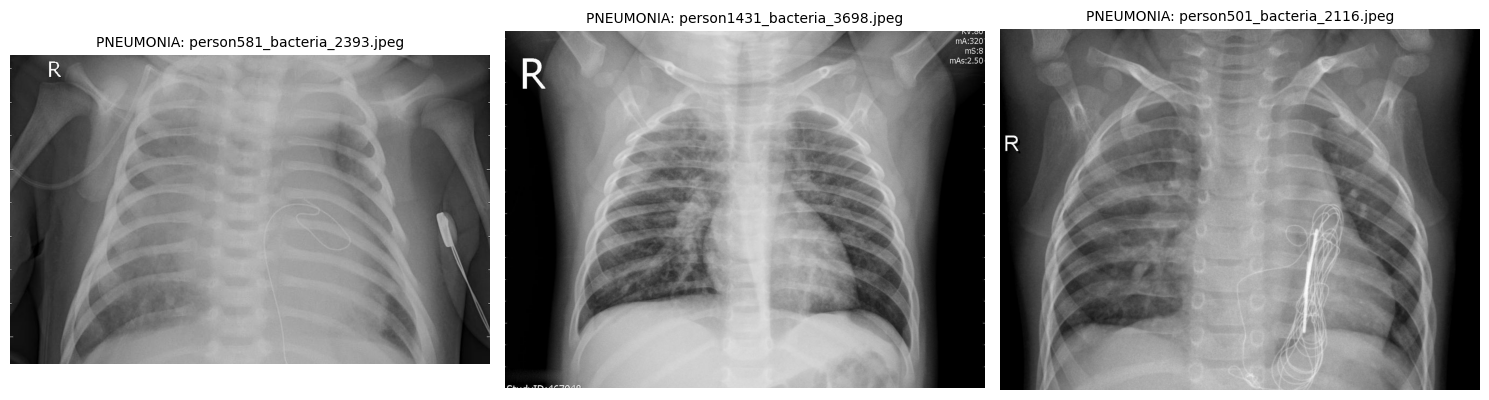

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def plot_random_samples(condition):
  path=f'chest_xray/train/{condition}'
  all_images=os.listdir(path)
  random_images=random.sample(all_images, 3)

  plt.figure(figsize=(15,10))
  for i, img_name in enumerate(random_images):
    img_path=os.path.join(path, img_name)
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"{condition}: {img_name}", fontsize=10)
    plt.axis('off')

  plt.tight_layout()
  plt.show()

print("Nasumični uzorci slika zdravih pluća (normal):")
plot_random_samples('NORMAL')

print("\n Nasumični uzorci slika pluća (pneumonia):")
plot_random_samples('PNEUMONIA')

Izrada baseline modela korištenjem transfer learninga (VGG16):

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model=models.vgg16(pretrained=True)

for param in model.features.parameters():
  param.requires_grad=False

num_features=model.classifier[6].in_features
model.classifier[6]=nn.Linear(num_features, 2)

#prebacivanje na gpu
device=torch.device("cuda"if torch.cuda.is_available() else "cpu")
model=model.to(device)

print(model.classifier)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 172MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


Definiranje loss funkcije i optimizatora (Adam):

In [ ]:
import torch.optim as optim

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
print("Loss i optimizator uspješno definirani")

Loss i optimizator uspješno definirani


Normalizacija i priprema podataka

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#VGG16 zahtijeva 224x224 i normalizaciju specifičnu za ImageNet
data_transforms=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

])

train_dataset=datasets.ImageFolder('chest_xray/train', transform=data_transforms)
test_dataset=datasets.ImageFolder('chest_xray/test', transform=data_transforms)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Uspješno učitano {len(train_dataset)} slika za trening")
print(f"Uspješno učitano {len(test_dataset)} slika za test")
print(f"Mapiranje klasa: {train_dataset.class_to_idx}")

Uspješno učitano 5216 slika za trening
Uspješno učitano 624 slika za test
Mapiranje klasa: {'NORMAL': 0, 'PNEUMONIA': 1}


Pomoćna fja za izračun metrika:

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def calculate_metrics(y_true, y_pred):
  acc=accuracy_score(y_true, y_pred)
  prec=precision_score(y_true, y_pred, zero_division=0)
  rec=recall_score(y_true, y_pred, zero_division=0)
  f1=f1_score(y_true, y_pred, zero_division=0)

  return acc, prec, rec, f1

Inicijalizacija rječnika za praćenje napretka:

In [ ]:
history={
    'train_loss': [], 'train_acc': [], 'train_prec': [], 'train_rec': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_prec': [], 'val_rec': [], 'val_f1': []
}

print("Rječnik za praćenje napretka uspješno inicijaliziran")

Rječnik za praćenje napretka uspješno inicijaliziran


Training Loop:

In [ ]:
import numpy as np
from tqdm import tqdm

def train_baseline_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(epochs):
        print(f"\nEpoha {epoch+1}/{epochs}")

        # TRENING
        model.train()
        train_loss, train_preds, train_targets = 0.0, [], []

        for inputs, labels in tqdm(train_loader, desc="Treniranje"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # resetiranje gradijenata
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() # backpropagation
            optimizer.step() # azuriranje tezina

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())



        # računanje metrika za trening
        t_loss = train_loss / len(train_loader.dataset)
        t_acc, t_prec, t_rec, t_f1 = calculate_metrics(train_targets, train_preds)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['train_prec'].append(t_prec)
        history['train_rec'].append(t_rec)
        history['train_f1'].append(t_f1)

        # VALIDACIJA
        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []

        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc="Validacija"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        v_loss = val_loss / len(test_loader.dataset)
        v_acc, v_prec, v_rec, v_f1 = calculate_metrics(val_targets, val_preds)

        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['val_prec'].append(v_prec)
        history['val_rec'].append(v_rec)
        history['val_f1'].append(v_f1)

        print(f"KRAJ EPOHE {epoch+1}")
        print(f"Trening - Loss: {t_loss:.4f}, Acc: {t_acc:.4f}, F1: {t_f1:.4f}")
        print(f"Validacija - Loss: {v_loss:.4f}, Acc: {v_acc:.4f}, F1: {v_f1:.4f}")

# pokretanje:
train_baseline_model(model, train_loader, test_loader, criterion, optimizer, epochs=5)


Epoha 1/5


Validacija: 100%|██████████| 20/20 [00:12<00:00,  1.55it/s]


KRAJ EPOHE 1
Trening - Loss: 0.4264, Acc: 0.9358, F1: 0.9568
Validacija - Loss: 1.1657, Acc: 0.8862, F1: 0.9141

Epoha 2/5


Validacija: 100%|██████████| 20/20 [00:13<00:00,  1.53it/s]


KRAJ EPOHE 2
Trening - Loss: 0.3590, Acc: 0.9603, F1: 0.9733
Validacija - Loss: 3.2665, Acc: 0.8269, F1: 0.8773

Epoha 3/5


...

KRAJ EPOHE 3
Trening - Loss: 0.1724, Acc: 0.9770, F1: 0.9845
Validacija - Loss: 2.3690, Acc: 0.8718, F1: 0.9057

Epoha 4/5


Validacija: 100%|██████████| 20/20 [00:12<00:00,  1.58it/s]


KRAJ EPOHE 4
Trening - Loss: 0.1767, Acc: 0.9818, F1: 0.9877
Validacija - Loss: 4.7995, Acc: 0.7564, F1: 0.8369

Epoha 5/5


Validacija: 100%|██████████| 20/20 [00:12<00:00,  1.60it/s]

KRAJ EPOHE 5
Trening - Loss: 0.1337, Acc: 0.9829, F1: 0.9885
Validacija - Loss: 8.3110, Acc: 0.6907, F1: 0.8016


Spremanje baseline modela

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model.state_dict(), '/content/drive/MyDrive/vgg16_baseline_pneumonia.pth')
print("Spremljeno na drive")

Mounted at /content/drive
Spremljeno na drive


Vizualizacija rezultata baseline modela.

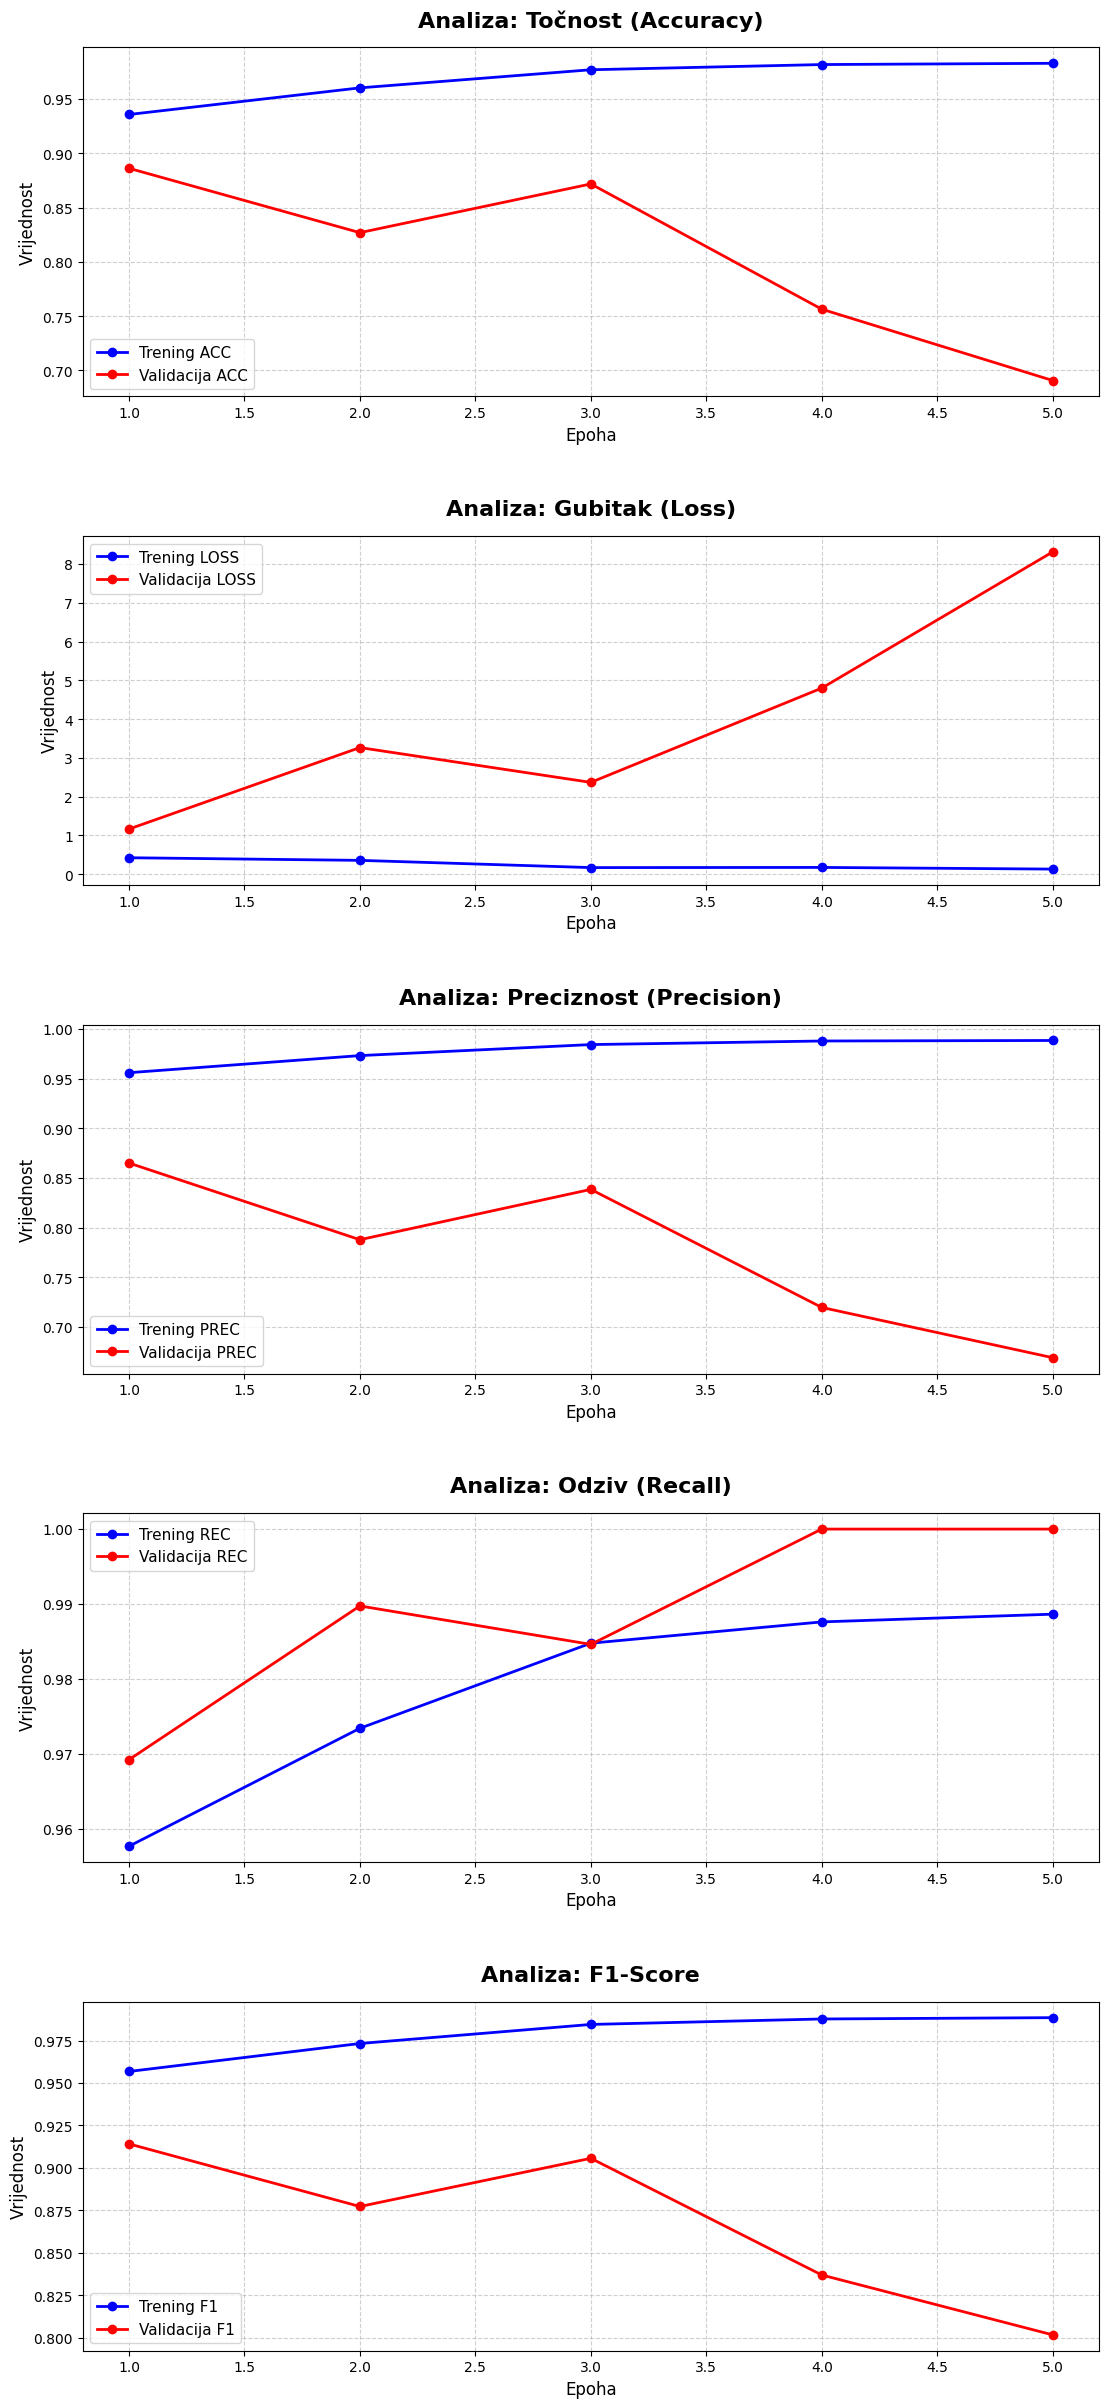

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    epochs = range(1, len(history['train_acc']) + 1)


    metrics = [
        ('acc', 'Točnost (Accuracy)'),
        ('loss', 'Gubitak (Loss)'),
        ('prec', 'Preciznost (Precision)'),
        ('rec', 'Odziv (Recall)'),
        ('f1', 'F1-Score')
    ]


    plt.figure(figsize=(12, 25))

    for i, (m_key, m_name) in enumerate(metrics, 1):
        plt.subplot(5, 1, i)

        train_values = history[f'train_{m_key}']
        val_values = history[f'val_{m_key}']

        plt.plot(epochs, train_values, 'b-o', linewidth=2, label=f'Trening {m_key.upper()}')
        plt.plot(epochs, val_values, 'r-o', linewidth=2, label=f'Validacija {m_key.upper()}')

        plt.title(f'Analiza: {m_name}', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Epoha', fontsize=12)
        plt.ylabel('Vrijednost', fontsize=12)
        plt.legend(loc='best', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.6)


        plt.tight_layout(pad=4.0)

    plt.show()


plot_metrics(history)

In [ ]:
import random

# Definiramo SVE dostupne indekse iz trening skupa
all_train_indices = list(range(len(train_dataset)))

# Fiksiramo prvih 10 slika koje će koristiti i AL i Random
initial_indices = random.sample(all_train_indices, 10)

print(f"Početni indeksi su spremni: {initial_indices}")

Početni indeksi su spremni: [2575, 2096, 3010, 3724, 4768, 1322, 269, 3483, 4424, 1201]


Priprema AL initial poola:

In [ ]:
from threading import active_count
import numpy as np
from torch.utils.data import Subset, DataLoader
#definirati početni broj slika:
INITIAL_SAMPLES=10 #smanjen sa 100 na 10

#uzimamo indekse svih slika iz trening skupa
all_indices=np.arange(len(train_dataset))
np.random.shuffle(all_indices)

#dijelimo na labeled i unlabeled(initial pool)
labeled_indices=all_indices[:INITIAL_SAMPLES].tolist()
unlabeled_indices=all_indices[INITIAL_SAMPLES:].tolist()

print(f"Početni set labeled: {len(labeled_indices)}")
print(f"Početni set unlabeled - initial pool: {len(unlabeled_indices)}")

#fja za kreiranje loadera od trenutno označenih slika
def get_active_loaders(labeled_indices):
  active_subset=Subset(train_dataset, labeled_indices)
  return DataLoader(active_subset, batch_size=32, shuffle=True)

active_loader=get_active_loaders(labeled_indices)



Početni set labeled: 10
Početni set unlabeled - initial pool: 5206


Sada model "vidi" samo 10 označenih slika, a preostale su u initial poolu - pravimo se da ne znamo njihovu labelu.

Fja za izbor slika s najvećom nesigurnošću modela:

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

def create_fresh_model():

    fresh_model = models.vgg16(pretrained=True)
    for param in fresh_model.parameters():
        param.requires_grad = True
    fresh_model.classifier[6] = nn.Linear(4096, 2)
    return fresh_model.to(device)

def get_uncertain_samples(model, unlabeled_indices, train_dataset, n_samples=10):
    model.eval()
    unlabeled_loader = DataLoader(Subset(train_dataset, unlabeled_indices), batch_size=64, shuffle=False)
    all_probs = []
    with torch.no_grad():
        for inputs, _ in unlabeled_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
    all_probs = torch.cat(all_probs)

    diff = torch.abs(all_probs[:,0] - all_probs[:,1])
    _, sorted_idx = torch.sort(diff)
    new_indices = [unlabeled_indices[i] for i in sorted_idx[:n_samples]]
    return new_indices

def evaluate_model_full(model, test_loader, criterion):
    model.eval()
    running_loss, total, correct = 0, 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = correct / total
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return test_loss, test_acc, prec, rec, f1

AL petlja +  metrike:

In [ ]:
# Postavke
N_ITERATIONS = 10
SAMPLES_PER_ITER = 10
EPOCHS_PER_ITER = 10

# Inicijalizacija modela i podataka
model_active = create_fresh_model()
optimizer_active = torch.optim.Adam(model_active.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

al_history = {k: [] for k in ['samples_count', 'test_acc', 'test_prec', 'test_rec', 'test_f1', 'test_loss']}

# Početni indeksi
labeled_indices = list(initial_indices)
unlabeled_indices = [idx for idx in all_train_indices if idx not in initial_indices]


for i in range(N_ITERATIONS):
    print(f"\nRunda {i+1}/10 (Broj slika: {len(labeled_indices)})")

    # 1. Treniranje
    model_active.train()
    active_loader = get_active_loaders(labeled_indices)
    for epoch in range(EPOCHS_PER_ITER):
        for inputs, labels in active_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_active.zero_grad()
            outputs = model_active(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_active.step()

    # 2. Evaluacija
    t_loss, t_acc, t_prec, t_rec, t_f1 = evaluate_model_full(model_active, test_loader, criterion)

    # 3. Spremanje rezultata
    al_history['samples_count'].append(len(labeled_indices))
    al_history['test_acc'].append(t_acc)
    al_history['test_prec'].append(t_prec)
    al_history['test_rec'].append(t_rec)
    al_history['test_f1'].append(t_f1)
    al_history['test_loss'].append(t_loss)

    print(f"Rezultat -> Acc: {t_acc:.4f} | F1: {t_f1:.4f} | Recall: {t_rec:.4f}")

    # 4. Odabir novih slika (Uncertainty Sampling)
    if i < N_ITERATIONS - 1:
        new_samples = get_uncertain_samples(model_active, unlabeled_indices, train_dataset, n_samples=SAMPLES_PER_ITER)
        labeled_indices.extend(new_samples)
        for idx in new_samples:
            unlabeled_indices.remove(idx)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Runda 1/10 (Broj slika: 10)
Rezultat -> Acc: 0.6554 | F1: 0.7826 | Recall: 0.9923

Runda 2/10 (Broj slika: 20)
Rezultat -> Acc: 0.7821 | F1: 0.8000 | Recall: 0.6974

Runda 3/10 (Broj slika: 30)
Rezultat -> Acc: 0.6699 | F1: 0.7894 | Recall: 0.9897

Runda 4/10 (Broj slika: 40)
Rezultat -> Acc: 0.7708 | F1: 0.8399 | Recall: 0.9615

Runda 5/10 (Broj slika: 50)
Rezultat -> Acc: 0.7500 | F1: 0.8304 | Recall: 0.9795

Runda 6/10 (Broj slika: 60)
Rezultat -> Acc: 0.7644 | F1: 0.8372 | Recall: 0.9692

Runda 7/10 (Broj slika: 70)
Rezultat -> Acc: 0.7740 | F1: 0.8428 | Recall: 0.9692

Runda 8/10 (Broj slika: 80)
Rezultat -> Acc: 0.7564 | F1: 0.8348 | Recall: 0.9846

Runda 9/10 (Broj slika: 90)
Rezultat -> Acc: 0.7612 | F1: 0.8382 | Recall: 0.9897

Runda 10/10 (Broj slika: 100)
Rezultat -> Acc: 0.8269 | F1: 0.8776 | Recall: 0.9923


Vizualizacija AL:

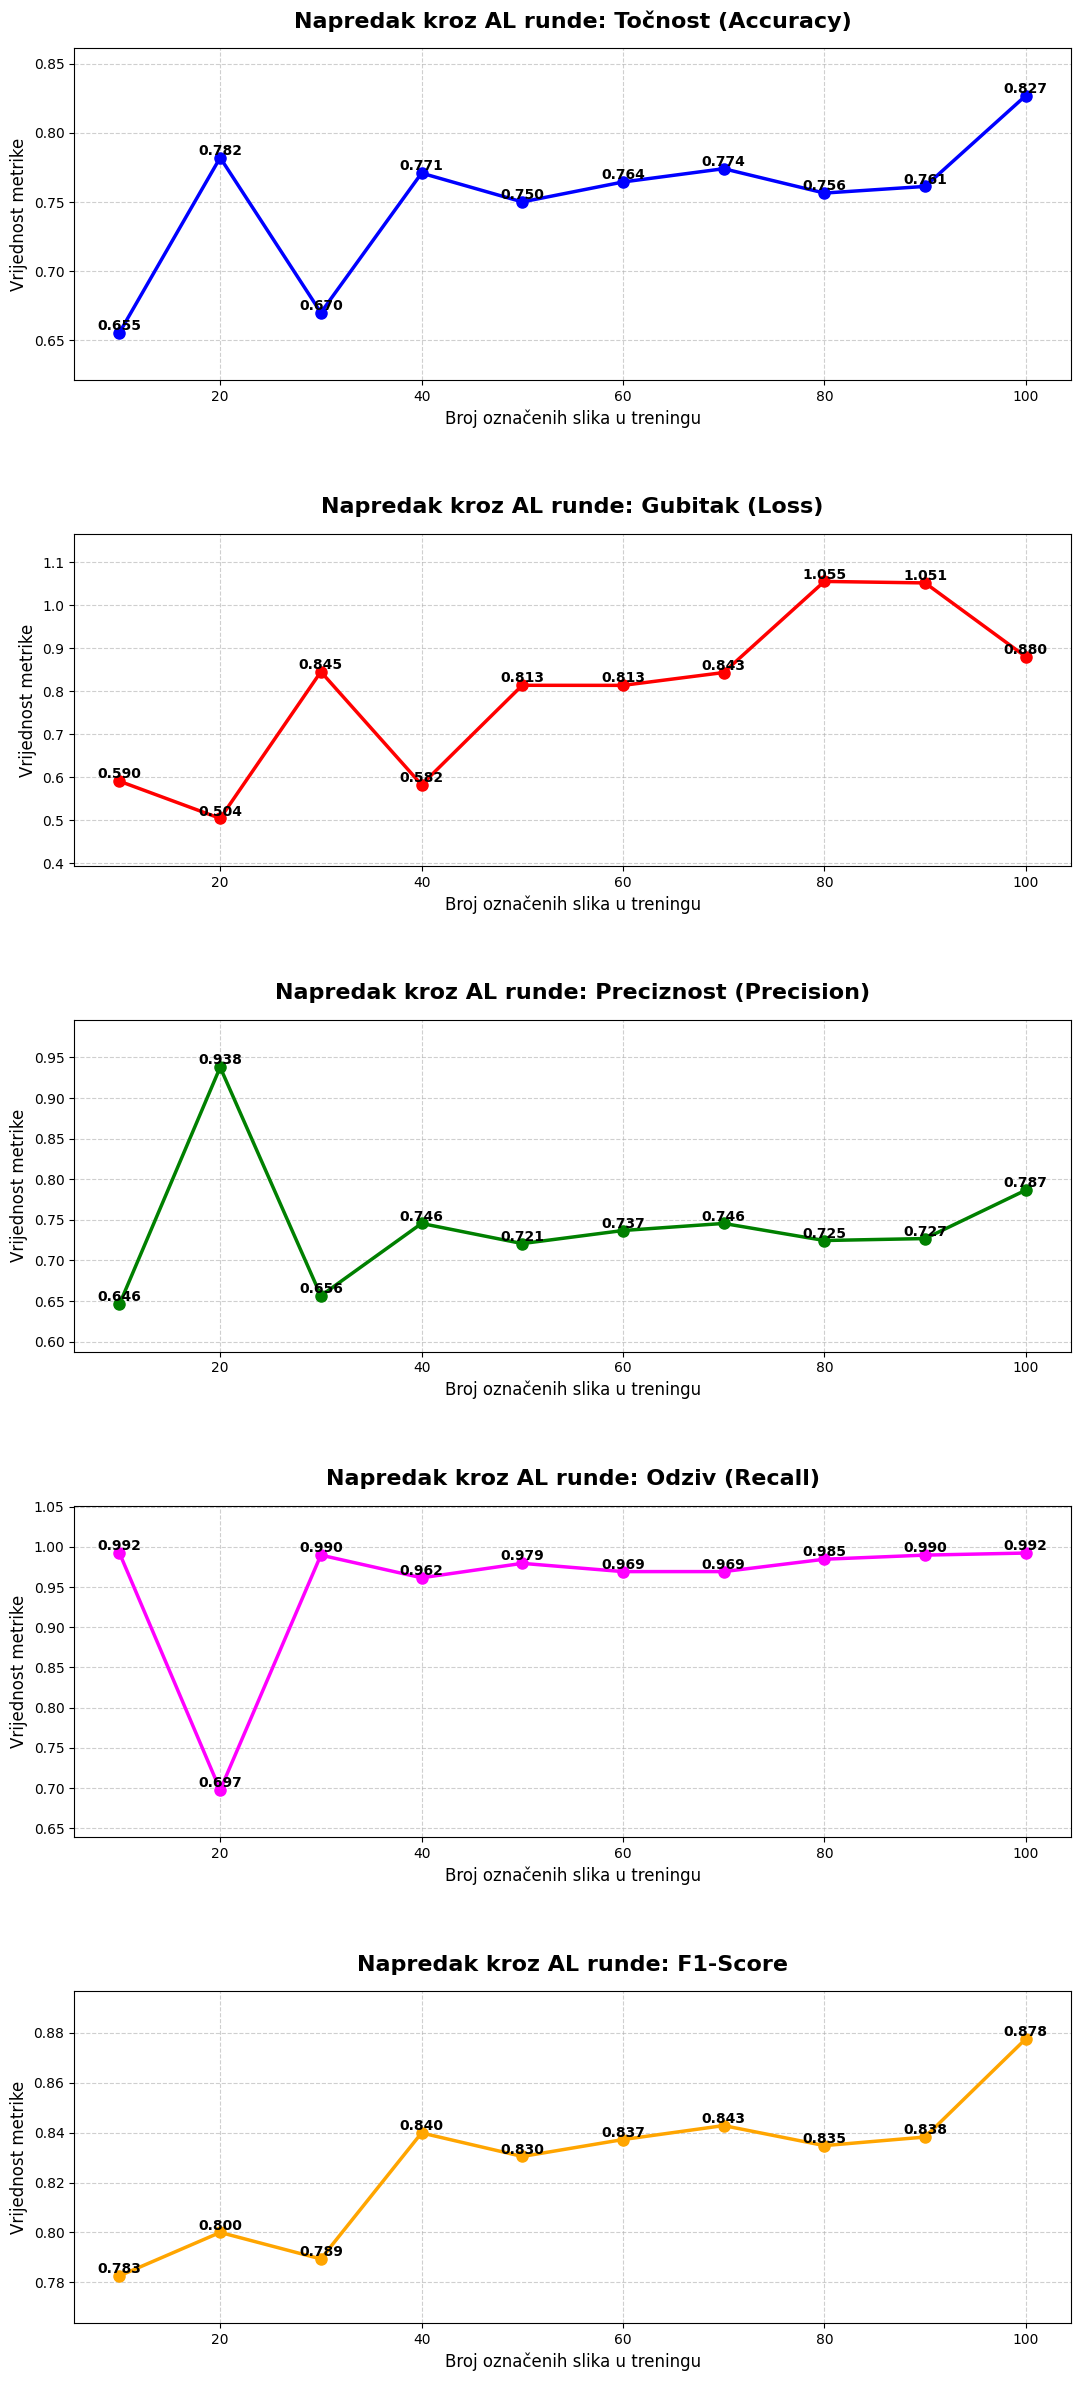

In [ ]:
import matplotlib.pyplot as plt

def plot_al_progress(history):
    x = history['samples_count']


    metrics = [
        ('test_acc', 'Točnost (Accuracy)', 'blue'),
        ('test_loss', 'Gubitak (Loss)', 'red'),
        ('test_prec', 'Preciznost (Precision)', 'green'),
        ('test_rec', 'Odziv (Recall)', 'magenta'),
        ('test_f1', 'F1-Score', 'orange')
    ]


    plt.figure(figsize=(12, 25))

    for i, (key, name, color) in enumerate(metrics, 1):

        plt.subplot(5, 1, i)


        plt.plot(x, history[key], marker='o', linestyle='-', color=color, linewidth=2.5, markersize=8)


        for val_x, val_y in zip(x, history[key]):
            plt.text(val_x, val_y, f'{val_y:.3f}', va='bottom', ha='center', fontsize=10, fontweight='bold')


        plt.title(f'Napredak kroz AL runde: {name}', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Broj označenih slika u treningu', fontsize=12)
        plt.ylabel('Vrijednost metrike', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)


        plt.margins(y=0.2)


    plt.tight_layout(pad=5.0)
    plt.show()


plot_al_progress(al_history)

Confusion matrix za finalni rezultat:

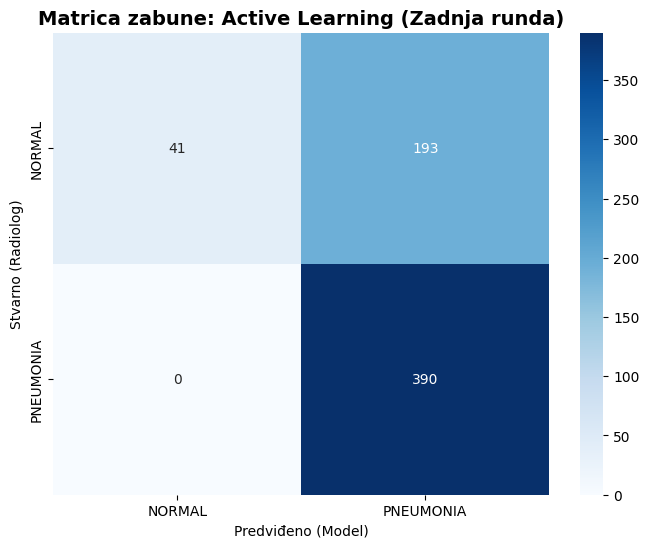

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_final_confusion_matrix(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())


    cm = confusion_matrix(all_labels, all_preds)


    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Predviđeno (Model)')
    plt.ylabel('Stvarno (Radiolog)')
    plt.title('Matrica zabune: Active Learning (Zadnja runda)', fontsize=14, fontweight='bold')
    plt.show()


plot_final_confusion_matrix(model, test_loader)

Random Sampling:

In [ ]:
import random


N_ITERATIONS = 10
SAMPLES_PER_ITER = 10
EPOCHS_PER_ITER = 10

# Inicijalizacija modela
model_random = create_fresh_model()
optimizer_random = torch.optim.Adam(model_random.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()


random_history = {
    'samples_count': [],
    'test_acc': [], 'test_loss': [],
    'test_prec': [], 'test_rec': [], 'test_f1': []
}


current_random_indices = list(initial_indices)
all_indices = list(range(len(train_dataset)))
available_for_random = [idx for idx in all_indices if idx not in initial_indices]

Random Sampling loop:

In [ ]:


for i in range(N_ITERATIONS):
    print(f"\nRunda {i+1}/10: Treniranje na {len(current_random_indices)} nasumičnih slika")


    random_loader = get_active_loaders(current_random_indices)


    model_random.train()
    for epoch in range(EPOCHS_PER_ITER):
        for inputs, labels in random_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_random.zero_grad()
            outputs = model_random(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_random.step()


    t_loss, t_acc, t_prec, t_rec, t_f1 = evaluate_model_full(model_random, test_loader, criterion)


    random_history['samples_count'].append(len(current_random_indices))
    random_history['test_acc'].append(t_acc)
    random_history['test_loss'].append(t_loss)
    random_history['test_prec'].append(t_prec)
    random_history['test_rec'].append(t_rec)
    random_history['test_f1'].append(t_f1)

    print(f"Rezultat -> Acc: {t_acc:.4f} | F1: {t_f1:.4f} | Recall: {t_rec:.4f}")


    if i < N_ITERATIONS - 1:
        new_samples = random.sample(available_for_random, SAMPLES_PER_ITER)
        current_random_indices.extend(new_samples)
        for idx in new_samples:
            available_for_random.remove(idx)




Runda 1/10: Treniranje na 10 nasumičnih slika
Rezultat -> Acc: 0.6907 | F1: 0.7971 | Recall: 0.9718

Runda 2/10: Treniranje na 20 nasumičnih slika
Rezultat -> Acc: 0.6971 | F1: 0.8013 | Recall: 0.9769

Runda 3/10: Treniranje na 30 nasumičnih slika
Rezultat -> Acc: 0.7244 | F1: 0.8162 | Recall: 0.9795

Runda 4/10: Treniranje na 40 nasumičnih slika
Rezultat -> Acc: 0.6891 | F1: 0.8004 | Recall: 0.9974

Runda 5/10: Treniranje na 50 nasumičnih slika
Rezultat -> Acc: 0.6923 | F1: 0.8025 | Recall: 1.0000

Runda 6/10: Treniranje na 60 nasumičnih slika
Rezultat -> Acc: 0.7532 | F1: 0.8341 | Recall: 0.9923

Runda 7/10: Treniranje na 70 nasumičnih slika
Rezultat -> Acc: 0.7516 | F1: 0.8332 | Recall: 0.9923

Runda 8/10: Treniranje na 80 nasumičnih slika
Rezultat -> Acc: 0.7837 | F1: 0.8512 | Recall: 0.9897

Runda 9/10: Treniranje na 90 nasumičnih slika
Rezultat -> Acc: 0.7869 | F1: 0.8530 | Recall: 0.9897

Runda 10/10: Treniranje na 100 nasumičnih slika
Rezultat -> Acc: 0.7837 | F1: 0.8512 | Rec

Svi rezultati (tablično)

In [ ]:
import pandas as pd

data = {
    'Slike': al_history['samples_count'],
    'AL_Acc': al_history['test_acc'],
    'Rand_Acc': random_history['test_acc'],
    'AL_Rec': al_history['test_rec'],
    'Rand_Rec': random_history['test_rec'],
    'AL_F1': al_history['test_f1'],
    'Rand_F1': random_history['test_f1']
}

df_usporedba = pd.DataFrame(data)
print("USPOREDNA TABLICA REZULTATA:")
print(df_usporedba.to_string(index=False))

USPOREDNA TABLICA REZULTATA:
 Slike   AL_Acc  Rand_Acc   AL_Rec  Rand_Rec    AL_F1  Rand_F1
    10 0.655449  0.690705 0.992308  0.971795 0.782609 0.797056
    20 0.782051  0.697115 0.697436  0.976923 0.800000 0.801262
    30 0.669872  0.724359 0.989744  0.979487 0.789366 0.816239
    40 0.770833  0.689103 0.961538  0.997436 0.839866 0.800412
    50 0.750000  0.692308 0.979487  1.000000 0.830435 0.802469
    60 0.764423  0.753205 0.969231  0.992308 0.837209 0.834052
    70 0.774038  0.751603 0.969231  0.992308 0.842809 0.833154
    80 0.756410  0.783654 0.984615  0.989744 0.834783 0.851158
    90 0.761218  0.786859 0.989744  0.989744 0.838219 0.853039
   100 0.826923  0.783654 0.992308  0.989744 0.877551 0.851158


Usporedni grafovi AL VS. Random Sampling

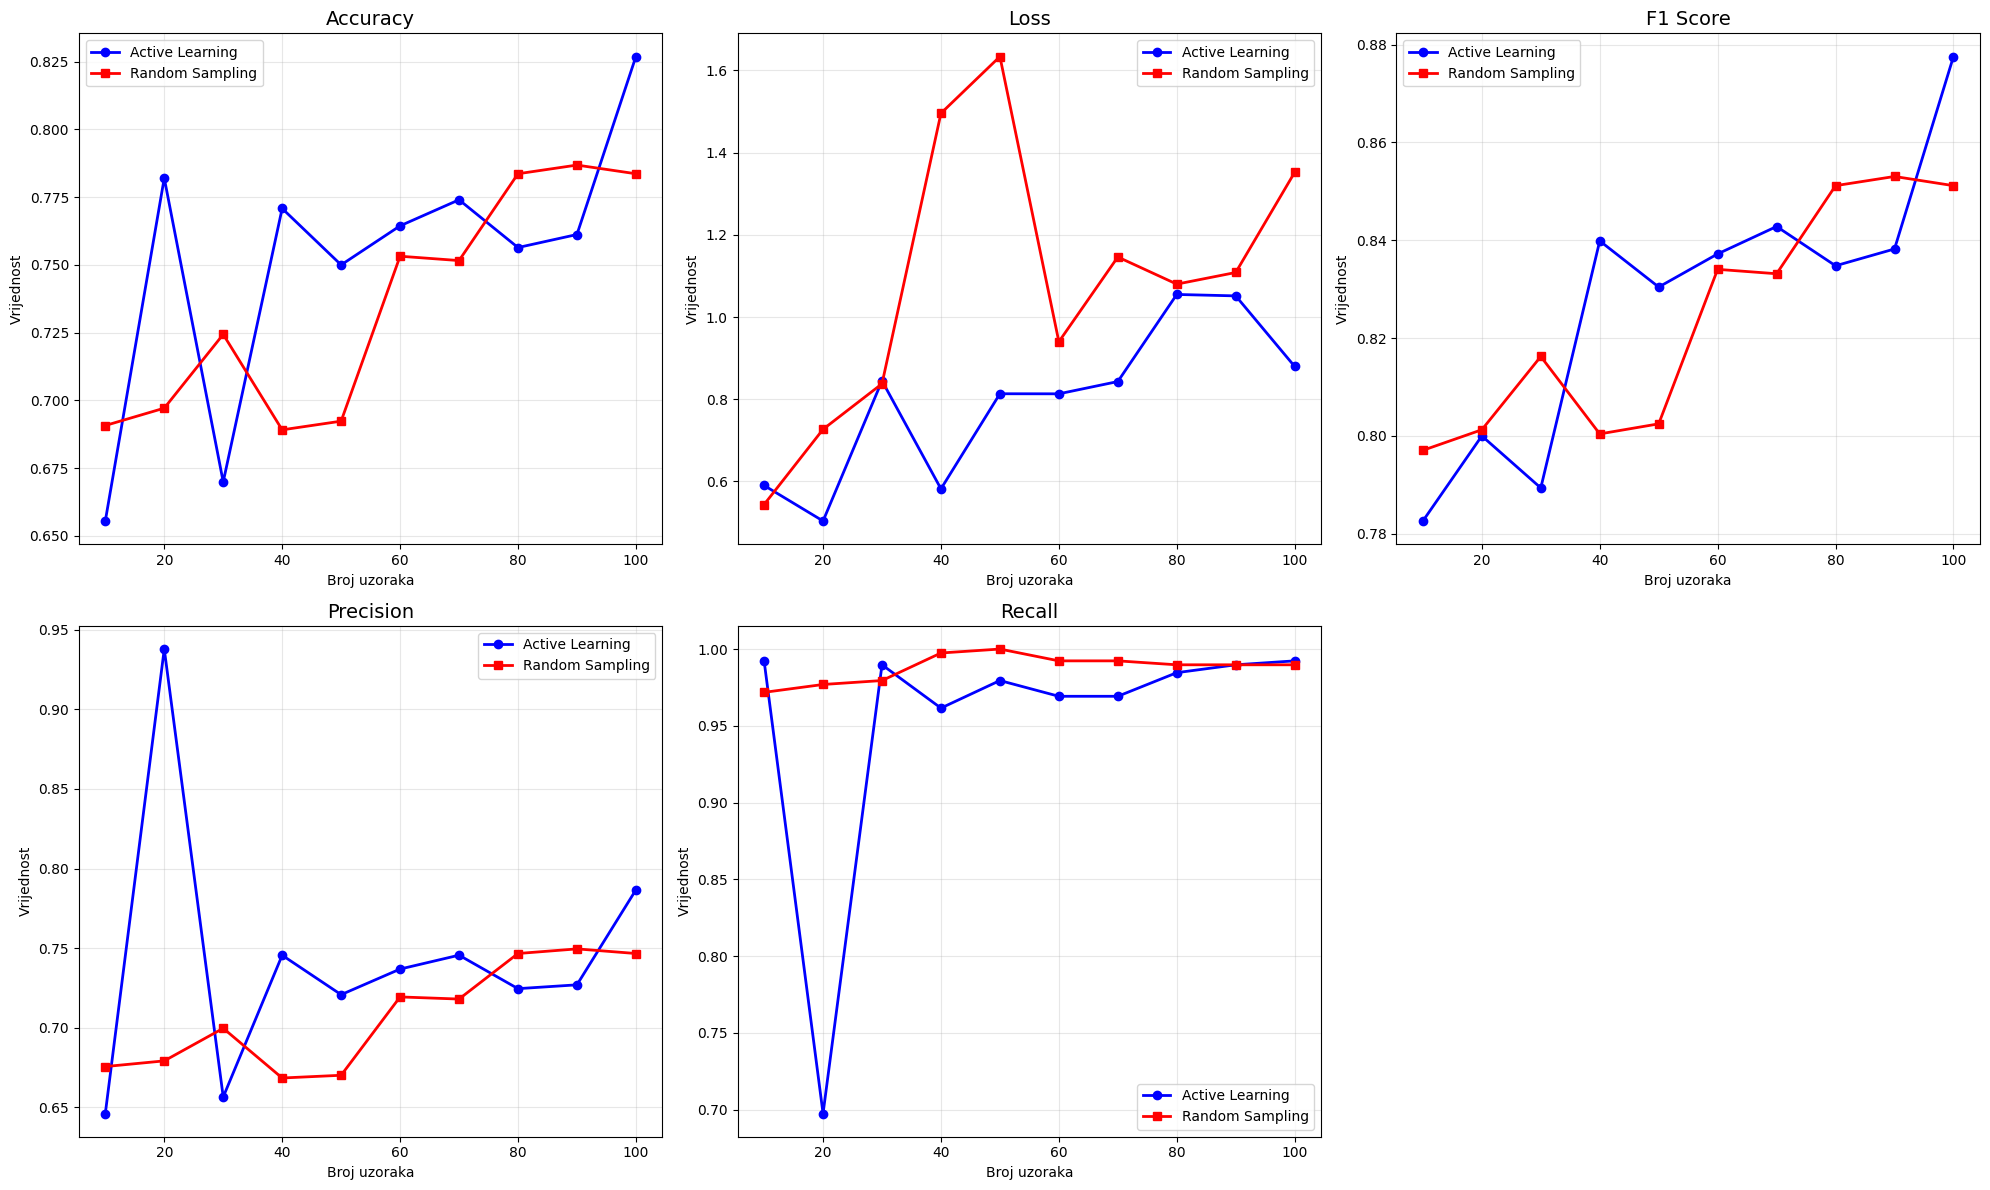

In [ ]:
import matplotlib.pyplot as plt

metrics = ['test_acc', 'test_loss', 'test_f1', 'test_prec', 'test_rec']
titles = ['Accuracy', 'Loss', 'F1 Score', 'Precision', 'Recall']

plt.figure(figsize=(20, 12))

for i, (metric, title) in enumerate(zip(metrics, titles)):
    plt.subplot(2, 3, i+1)
    plt.plot(al_history['samples_count'], al_history[metric], 'b-o', label='Active Learning', linewidth=2)
    plt.plot(random_history['samples_count'], random_history[metric], 'r-s', label='Random Sampling', linewidth=2)
    plt.title(title, fontsize=14)
    plt.xlabel('Broj uzoraka')
    plt.ylabel('Vrijednost')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()